In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

from google.colab import files

uploaded = files.upload()

df = pd.read_csv("StudentPerformanceFactors.csv")

df.head()

Saving StudentPerformanceFactors.csv to StudentPerformanceFactors (1).csv


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
"Estandarizar nombres de columnas"
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns

Index(['hours_studied', 'attendance', 'parental_involvement',
       'access_to_resources', 'extracurricular_activities', 'sleep_hours',
       'previous_scores', 'motivation_level', 'internet_access',
       'tutoring_sessions', 'family_income', 'teacher_quality', 'school_type',
       'peer_influence', 'physical_activity', 'learning_disabilities',
       'parental_education_level', 'distance_from_home', 'gender',
       'exam_score'],
      dtype='object')

In [ ]:
"Revisión inicial"
print("Dimensiones del dataset:")
print(df.shape)

print("\nPrimeras filas:")
display(df.head())

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores faltantes:")
print(df.isnull().sum())

print("\nDuplicados:")
print(df.duplicated().sum())
df.info()

In [4]:
"Limpieza básica"
df["exam_score"] = pd.to_numeric(df["exam_score"], errors="coerce")
df = df.dropna(subset=["exam_score"])
df = df[df["exam_score"].between(0, 100)].copy()

print(df.shape)

(6606, 20)


In [5]:
"Limpiamos espacios en variables categóricas"
categoricas = df.select_dtypes(include=["object", "string"]).columns

for col in categoricas:
    df[col] = df[col].astype("string").str.strip()

Durante la limpieza se eliminaron registros duplicados en caso de existir
y se verificó que Exam_Score se encontrara dentro de un rango válido de
0 a 100. Se detectó un registro con un valor de 101, por lo que fue
eliminado.

No se imputaron todavía los valores faltantes de las variables predictoras,
ya que este proceso se realizará posteriormente dentro del pipeline usando
únicamente los datos de entrenamiento. Esto ayuda a evitar fuga de
información.

In [6]:
"Explorar Exam_Score"
df["exam_score"].describe()

,exam_score
count,6606.000000
mean,67.230548
std,3.868502
min,55.000000
25%,65.000000
50%,67.000000
75%,69.000000
max,100.000000


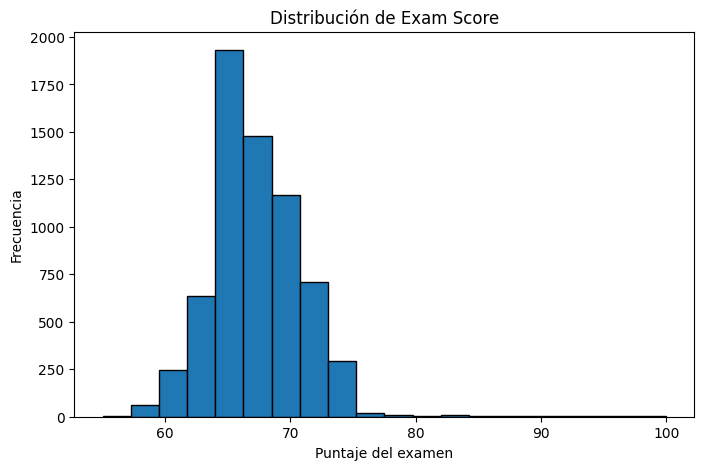

In [7]:
"Histograma"
plt.figure(figsize=(8, 5))

plt.hist(df["exam_score"], bins=20, edgecolor="black")

plt.title("Distribución de Exam Score")
plt.xlabel("Puntaje del examen")
plt.ylabel("Frecuencia")

plt.show()

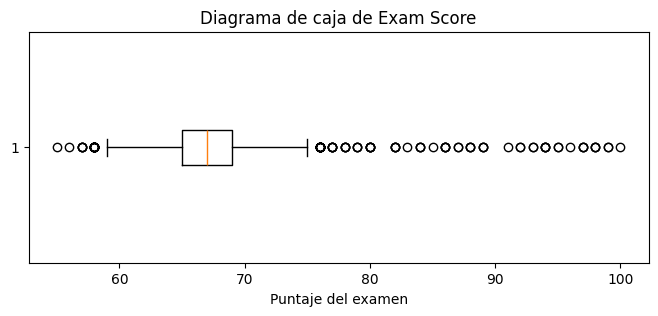

In [8]:
"Boxplot"
plt.figure(figsize=(8, 3))

plt.boxplot(df["exam_score"], vert=False)

plt.title("Diagrama de caja de Exam Score")
plt.xlabel("Puntaje del examen")

plt.show()

La distribución de Exam_Score permite observar cómo se concentran los
puntajes de los estudiantes y detectar posibles valores extremos.

El histograma muestra la frecuencia de los diferentes puntajes, mientras
que el diagrama de caja permite identificar la mediana, la dispersión y
posibles valores atípicos.

Estos valores extremos no se eliminan automáticamente, ya que pueden
representar variaciones reales en el desempeño de los estudiantes.

In [9]:
"Matriz de correlación"
numericas = df.select_dtypes(include=np.number)

correlacion = numericas.corr()

correlacion

,hours_studied,attendance,sleep_hours,previous_scores,tutoring_sessions,physical_activity,exam_score
hours_studied,1.000000,-0.010188,0.011103,0.024630,-0.014799,0.004619,0.446514
attendance,-0.010188,1.000000,-0.015756,-0.020487,0.013661,-0.022446,0.582458
sleep_hours,0.011103,-0.015756,1.000000,-0.021622,-0.011922,-0.000375,-0.016194
previous_scores,0.024630,-0.020487,-0.021622,1.000000,-0.013669,-0.011281,0.174461
tutoring_sessions,-0.014799,0.013661,-0.011922,-0.013669,1.000000,0.017730,0.153754
physical_activity,0.004619,-0.022446,-0.000375,-0.011281,0.017730,1.000000,0.027943
exam_score,0.446514,0.582458,-0.016194,0.174461,0.153754,0.027943,1.000000


In [10]:
"Ver relacion con Exam_Score"
correlacion_exam = (
    correlacion["exam_score"]
    .sort_values(ascending=False)
)

correlacion_exam

,exam_score
exam_score,1.000000
attendance,0.582458
hours_studied,0.446514
previous_scores,0.174461
tutoring_sessions,0.153754
physical_activity,0.027943
sleep_hours,-0.016194


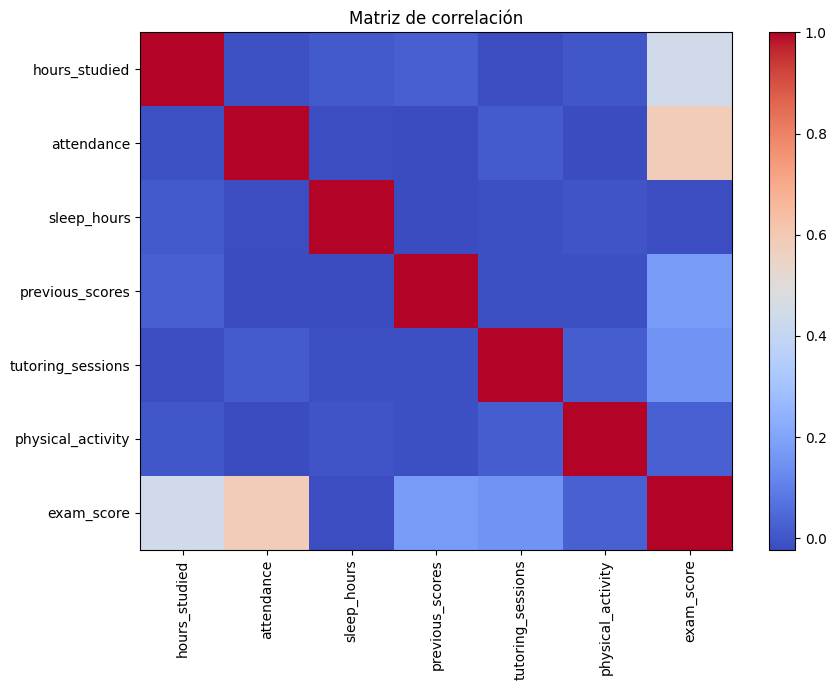

In [11]:
"Matriz visual"
plt.figure(figsize=(9, 7))

plt.imshow(correlacion, cmap="coolwarm", aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlacion.columns)),
    correlacion.columns,
    rotation=90
)

plt.yticks(
    range(len(correlacion.columns)),
    correlacion.columns
)

plt.title("Matriz de correlación")

plt.tight_layout()
plt.show()

La matriz de correlación muestra que la asistencia y las horas de estudio presentan las relaciones positivas más claras con Exam_Score. Los puntajes anteriores y las sesiones de tutoría también muestran cierta relación positiva, mientras que las horas de sueño y la actividad física presentan una relación lineal menor. Por ello, estas variables serán consideradas junto con otros factores categóricos durante el modelado.

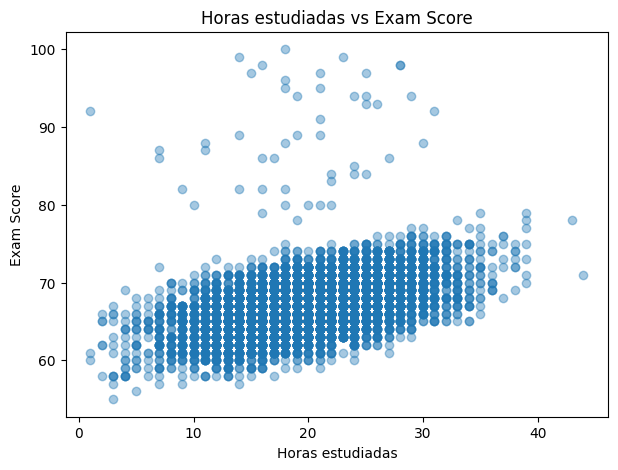

In [12]:
"Diagramas de dispersión"
plt.figure(figsize=(7, 5))

plt.scatter(
    df["hours_studied"],
    df["exam_score"],
    alpha=0.4
)

plt.xlabel("Horas estudiadas")
plt.ylabel("Exam Score")
plt.title("Horas estudiadas vs Exam Score")

plt.show()

Se observa una tendencia positiva entre las horas estudiadas y el puntaje del examen. Los estudiantes que dedican más horas al estudio tienden a obtener mayores puntajes, aunque existe dispersión en los resultados y algunos valores atípicos. Esto indica que las horas de estudio pueden contribuir a la predicción de Exam_Score, pero no son el único factor que influye en el desempeño.

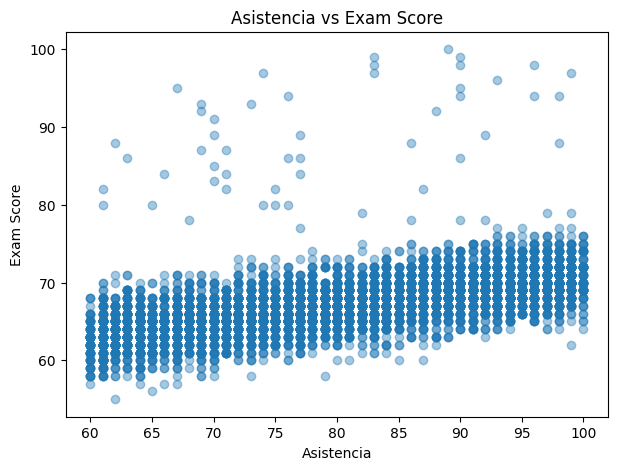

In [13]:
"Asistencia"
plt.figure(figsize=(7, 5))

plt.scatter(
    df["attendance"],
    df["exam_score"],
    alpha=0.4
)

plt.xlabel("Asistencia")
plt.ylabel("Exam Score")
plt.title("Asistencia vs Exam Score")

plt.show()

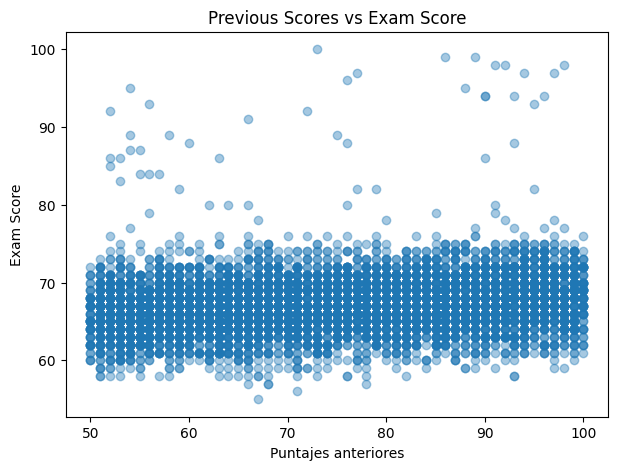

In [14]:
"Puntuajes Anteriores"
plt.figure(figsize=(7, 5))

plt.scatter(
    df["previous_scores"],
    df["exam_score"],
    alpha=0.4
)

plt.xlabel("Puntajes anteriores")
plt.ylabel("Exam Score")
plt.title("Previous Scores vs Exam Score")

plt.show()

La asistencia presenta una relación positiva clara con Exam_Score, ya que los estudiantes con mayores porcentajes de asistencia tienden a obtener puntajes más altos. Por otro lado, Previous_Scores muestra una relación positiva más débil y una mayor dispersión. Esto sugiere que ambas variables pueden contribuir al modelo, aunque la asistencia parece tener una mayor capacidad explicativa.

In [20]:
orden = ["Low", "Medium", "High"]

df["motivation_level"] = pd.Categorical(
    df["motivation_level"],
    categories=orden,
    ordered=True
)

df["parental_involvement"] = pd.Categorical(
    df["parental_involvement"],
    categories=orden,
    ordered=True
)

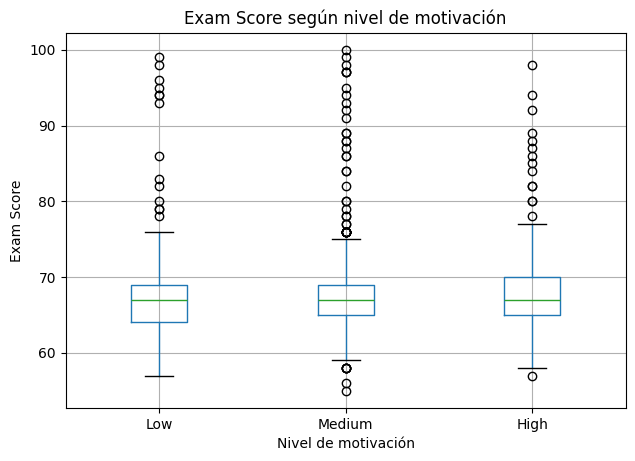

In [21]:
"Analizar variables categóricas"
df.boxplot(
    column="exam_score",
    by="motivation_level",
    figsize=(7, 5)
)

plt.title("Exam Score según nivel de motivación")
plt.suptitle("")
plt.xlabel("Nivel de motivación")
plt.ylabel("Exam Score")

plt.show()

Los diagramas de caja muestran que el nivel de motivación presenta diferencias relativamente pequeñas en Exam_Score entre sus categorías. En cambio, la participación de los padres muestra una tendencia más clara, donde los estudiantes con mayor participación parental presentan puntajes ligeramente superiores. Por ello, ambas variables pueden ser consideradas en el modelo, especialmente en combinación con otros factores académicos.

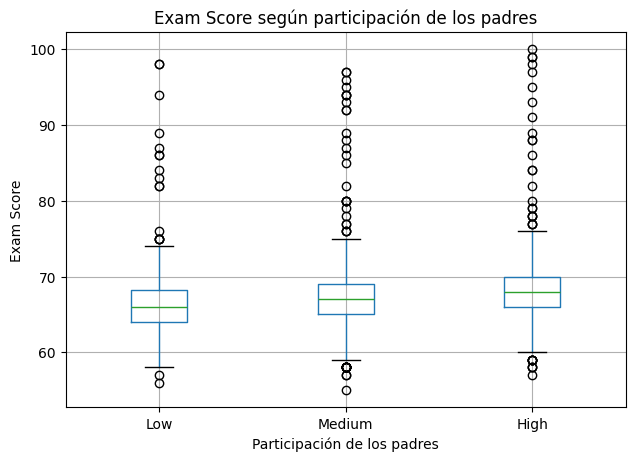

In [22]:
"Participación de los padres"
df.boxplot(
    column="exam_score",
    by="parental_involvement",
    figsize=(7, 5)
)

plt.title("Exam Score según participación de los padres")
plt.suptitle("")
plt.xlabel("Participación de los padres")
plt.ylabel("Exam Score")

plt.show()

Los diagramas de caja muestran que el nivel de motivación presenta diferencias relativamente pequeñas en Exam_Score entre sus categorías. En cambio, la participación de los padres muestra una tendencia más clara, donde los estudiantes con mayor participación parental presentan puntajes ligeramente superiores. Por ello, ambas variables pueden ser consideradas en el modelo, especialmente en combinación con otros factores académicos.

In [17]:
"Selección de variables"
numeric_features = [
    "hours_studied",
    "attendance",
    "previous_scores",
    "tutoring_sessions",
    "sleep_hours",
    "physical_activity"
]

In [18]:
"Categóricas con orden"
ordinal_features = [
    "parental_involvement",
    "access_to_resources",
    "motivation_level",
    "family_income",
    "teacher_quality"
]

In [19]:
"Categóricas nominales"
nominal_features = [
    "extracurricular_activities",
    "internet_access",
    "school_type",
    "learning_disabilities"
]

Se seleccionaron variables académicas como las horas de estudio,
asistencia, puntajes anteriores y sesiones de tutoría debido a su relación
directa con el desempeño académico.

También se incluyeron características personales y del entorno, como
motivación, participación de los padres, acceso a recursos, calidad del
docente y nivel de ingresos.

Finalmente, se incorporaron variables nominales como el tipo de escuela,
acceso a Internet y participación en actividades extracurriculares, ya
que pueden aportar información adicional al modelo aunque su relación
con Exam_Score no pueda analizarse directamente mediante correlación
de Pearson.

In [39]:
"Crear X y Y"
X = df[selected_features].copy()
y = df["exam_score"].copy()

# Convertir variables categóricas a object y normalizar valores faltantes
categorical_features = ordinal_features + nominal_features

for col in categorical_features:
    X[col] = X[col].astype(object)
    X[col] = X[col].where(pd.notna(X[col]), np.nan)


In [40]:
"Comprobamos"
print("X:", X.shape)
print("y:", y.shape)

display(X.head())
display(y.head())

X: (6606, 15)
y: (6606,)


,hours_studied,attendance,previous_scores,tutoring_sessions,sleep_hours,physical_activity,parental_involvement,access_to_resources,motivation_level,family_income,teacher_quality,extracurricular_activities,internet_access,school_type,learning_disabilities
0,23,84,73,0,7,3,Low,High,Low,Low,Medium,No,Yes,Public,No
1,19,64,59,2,8,4,Low,Medium,Low,Medium,Medium,No,Yes,Public,No
2,24,98,91,2,7,4,Medium,Medium,Medium,Medium,Medium,Yes,Yes,Public,No
3,29,89,98,1,8,4,Low,Medium,Medium,Medium,Medium,Yes,Yes,Public,No
4,19,92,65,3,6,4,Medium,Medium,Medium,Medium,High,Yes,Yes,Public,No


,exam_score
0,67
1,61
2,74
3,71
4,70


In [41]:
"División 80 % / 20 %"
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Entrenamiento:")
print(X_train.shape)
print(y_train.shape)

print("\nPrueba:")
print(X_test.shape)
print(y_test.shape)

Entrenamiento:
(5284, 15)
(5284,)

Prueba:
(1322, 15)
(1322,)


Se utilizó el 80 % de los datos para entrenamiento y el 20 % para prueba.

Se estableció random_state=42 para que la división del dataset sea
reproducible. Esto significa que al ejecutar nuevamente el notebook se
obtendrán los mismos registros en entrenamiento y prueba, permitiendo
comparar los modelos bajo las mismas condiciones.

In [42]:
"Pipeline numérico"
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

Imputar nulos con la mediana.
Escalar con StandardScaler.

In [43]:
"Pipeline ordinal"
ordinal_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "ordinal",
        OrdinalEncoder(
            categories=[
                ["Low", "Medium", "High"],
                ["Low", "Medium", "High"],
                ["Low", "Medium", "High"],
                ["Low", "Medium", "High"],
                ["Low", "Medium", "High"]
            ],
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )
    )
])

Low < Medium < High

In [44]:
"Pipeline categórico nominal"
nominal_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        )
    )
])

In [45]:
"ColumnTransformer"
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "ordinal",
        ordinal_pipeline,
        ordinal_features
    ),
    (
        "nominal",
        nominal_pipeline,
        nominal_features
    )
])

Se construyó un ColumnTransformer para aplicar diferentes tratamientos
según el tipo de variable.

Las variables numéricas son imputadas utilizando la mediana y después
estandarizadas con StandardScaler.

Las variables categóricas ordinales son codificadas respetando el orden
Low, Medium y High.

Por otro lado, las variables nominales son transformadas mediante
One-Hot Encoding.

Estas transformaciones se encuentran dentro de un pipeline, por lo que
se ajustarán únicamente utilizando el conjunto de entrenamiento,
evitando así fuga de información del conjunto de prueba.

In [46]:
"Línea base con DummyRegressor"
dummy = DummyRegressor(strategy="mean")

dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

A todos los estudiantes les voy a predecir el promedio.

In [47]:
"Función para evaluar modelos"
def evaluar_modelo(nombre, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2 = r2_score(y_real, y_pred)

    return {
        "Modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

demostrar que los modelos realmente superan al baseline

In [48]:
"Evaluamos baseline"
resultados = []

resultados.append(
    evaluar_modelo(
        "Dummy Regressor",
        y_test,
        y_pred_dummy
    )
)

pd.DataFrame(resultados)

,Modelo,MAE,RMSE,R2
0,Dummy Regressor,2.762923,3.640097,-0.001972


Al ser prácticamente 0, indica que este modelo no explica realmente la variación de las calificaciones. Que sea ligeramente negativo solo significa que, sobre el conjunto de prueba, terminó siendo mínimamente peor que predecir directamente su media.

In [49]:
"Modelo 1 — Regresión Lineal"
modelo_lineal = Pipeline([
    (
        "preprocessor",
        clone(preprocessor)
    ),
    (
        "modelo",
        LinearRegression()
    )
])

In [50]:
"Entrenamos"
modelo_lineal.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['hours_studied',
                                                   'attendance',
                                                   'previous_scores',
                                                   'tutoring_sessions',
                                                   'sleep_hours',
                                                   'physical_activity']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  (...
                                                  ['parental_involvement',
                                                   'access_to_resources',
                                                   'motivation_level',
                                                   'family_income',
                                                   'teacher_quality']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['extracurricular_activities',
                                                   'internet_access',
                                                   'school_type',
                                                   'learning_disabilities'])])),
                ('modelo', LinearRegression())])

In [53]:
"Predecimos"
y_pred_lineal = modelo_lineal.predict(X_test)

In [52]:
"Evaluamos"
resultados.append(
    evaluar_modelo(
        "Regresión Lineal",
        y_test,
        y_pred_lineal
    )
)

pd.DataFrame(resultados)

,Modelo,MAE,RMSE,R2
0,Dummy Regressor,2.762923,3.640097,-0.001972
1,Regresión Lineal,0.661513,1.643002,0.795870


La regresión lineal presentó un desempeño considerablemente mejor que el modelo base. El MAE disminuyó de 2.76 a 0.66 y el R² aumentó de aproximadamente 0 a 0.796. Esto indica que las variables seleccionadas permiten explicar una parte importante de la variación en Exam_Score y realizar predicciones mucho más precisas que una predicción constante.

In [55]:
"Modelo 2 — Ridge"
modelo_ridge = Pipeline([
    (
        "preprocessor",
        clone(preprocessor)
    ),
    (
        "modelo",
        Ridge(alpha=1.0)
    )
])

In [56]:
"Entrenar"
modelo_ridge.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['hours_studied',
                                                   'attendance',
                                                   'previous_scores',
                                                   'tutoring_sessions',
                                                   'sleep_hours',
                                                   'physical_activity']),
                                                 ('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  (...
                                                  ['parental_involvement',
                                                   'access_to_resources',
                                                   'motivation_level',
                                                   'family_income',
                                                   'teacher_quality']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['extracurricular_activities',
                                                   'internet_access',
                                                   'school_type',
                                                   'learning_disabilities'])])),
                ('modelo', Ridge())])

In [59]:
"Predecir"
y_pred_ridge = modelo_ridge.predict(X_test)

In [62]:
"Evaluar"
resultados.append(
    evaluar_modelo(
        "Ridge",
        y_test,
        y_pred_ridge
    )
)

pd.DataFrame(resultados)

,Modelo,MAE,RMSE,R2
0,Dummy Regressor,2.762923,3.640097,-0.001972
1,Regresión Lineal,0.661513,1.643002,0.795870
2,Ridge,0.661563,1.643008,0.795869
3,Ridge,0.661563,1.643008,0.795869
4,Ridge,0.661563,1.643008,0.795869
5,Ridge,0.661563,1.643008,0.795869


Tanto la Regresión Lineal como Ridge superaron ampliamente al modelo base. Ambos obtuvieron un MAE cercano a 0.66, un RMSE de aproximadamente 1.64 y un R² cercano a 0.796. La diferencia entre ambos modelos fue mínima, por lo que la regularización aplicada por Ridge no produjo una mejora relevante en este caso.

In [63]:
"Comparación final"
resultados_df = pd.DataFrame(resultados)

resultados_df

,Modelo,MAE,RMSE,R2
0,Dummy Regressor,2.762923,3.640097,-0.001972
1,Regresión Lineal,0.661513,1.643002,0.795870
2,Ridge,0.661563,1.643008,0.795869
3,Ridge,0.661563,1.643008,0.795869
4,Ridge,0.661563,1.643008,0.795869
5,Ridge,0.661563,1.643008,0.795869


In [66]:
"Mas limpio"
resultados_df = pd.DataFrame(resultados)

resultados_df = resultados_df.drop_duplicates(
    subset=["Modelo"],
    keep="first"
).reset_index(drop=True)

resultados_df.round(4)

,Modelo,MAE,RMSE,R2
0,Dummy Regressor,2.7629,3.6401,-0.0020
1,Regresión Lineal,0.6615,1.6430,0.7959
2,Ridge,0.6616,1.6430,0.7959


El MAE representa cuántos puntos se equivoca el modelo, en promedio, al estimar Exam_Score. La línea base presenta un MAE de aproximadamente 2.76 puntos, mientras que la Regresión Lineal y Ridge reducen este error a cerca de 0.66 puntos. Considerando que Exam_Score se expresa en una escala de 0 a 100, este error promedio es relativamente pequeño y muestra una mejora considerable frente a predecir simplemente el promedio.

El RMSE también mide el error de las predicciones, pero eleva los errores al cuadrado antes de calcular el promedio. Por esta razón, penaliza con mayor intensidad las predicciones que se alejan considerablemente del valor real. En la Regresión Lineal el RMSE es de aproximadamente 1.64 puntos, superior al MAE de 0.66. Esta diferencia indica que existen algunos estudiantes para los cuales el modelo comete errores considerablemente mayores, especialmente en ciertos puntajes extremos.

Finalmente, el R² indica qué proporción de la variación de Exam_Score puede ser explicada por las variables incluidas en el modelo. La Regresión Lineal obtuvo un R² aproximado de 0.796, lo que significa que explica cerca del 79.6 % de la variabilidad observada en los puntajes del conjunto de prueba. Aunque el ajuste es bueno como primera aproximación, todavía existe alrededor de un 20 % de variación que no está siendo explicada por las características utilizadas.

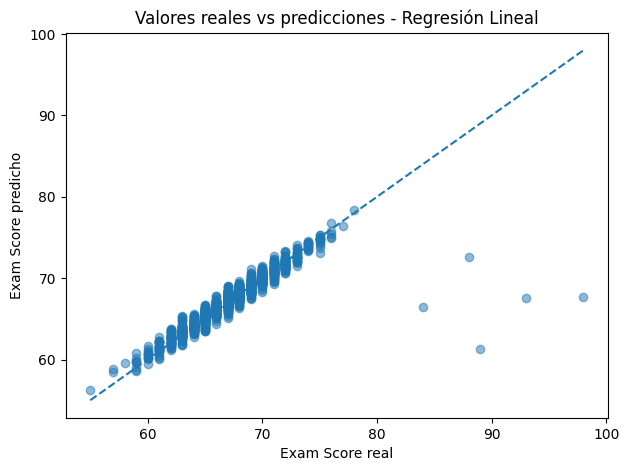

In [65]:
"Gráfica: predicción vs valor real"
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_pred_lineal,
    alpha=0.5
)

minimo = min(y_test.min(), y_pred_lineal.min())
maximo = max(y_test.max(), y_pred_lineal.max())

plt.plot(
    [minimo, maximo],
    [minimo, maximo],
    linestyle="--"
)

plt.xlabel("Exam Score real")
plt.ylabel("Exam Score predicho")
plt.title("Valores reales vs predicciones - Regresión Lineal")

plt.show()

La gráfica de valores reales contra predicciones muestra que la mayoría de las observaciones se encuentran cercanas a la línea ideal, especialmente para puntajes entre 60 y 78. Esto indica un buen ajuste general del modelo. Sin embargo, se observa que algunos puntajes reales altos son subestimados, lo que muestra que el modelo tiene mayor dificultad para predecir correctamente los casos extremos.

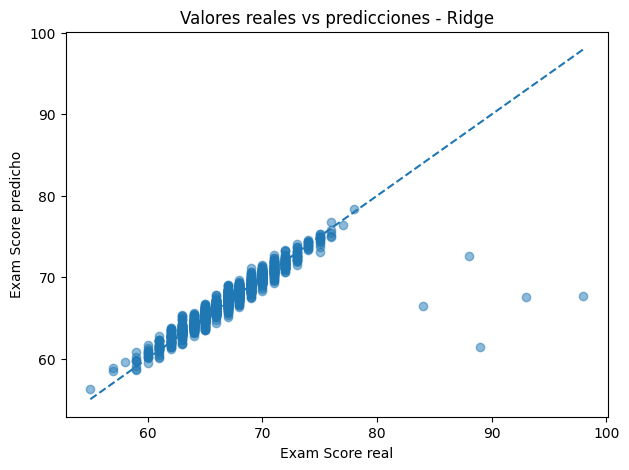

In [68]:
"Ridge"
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_pred_ridge,
    alpha=0.5
)

minimo = min(y_test.min(), y_pred_ridge.min())
maximo = max(y_test.max(), y_pred_ridge.max())

plt.plot(
    [minimo, maximo],
    [minimo, maximo],
    linestyle="--"
)

plt.xlabel("Exam Score real")
plt.ylabel("Exam Score predicho")
plt.title("Valores reales vs predicciones - Ridge")

plt.show()

Las gráficas de valores reales contra valores predichos muestran comportamientos prácticamente iguales para Regresión Lineal y Ridge, lo cual coincide con sus métricas similares. La mayor parte de las observaciones se concentra cerca de la línea de predicción perfecta. Sin embargo, ambos modelos presentan mayores errores para algunos estudiantes con puntajes reales muy altos, los cuales tienden a ser subestimados.

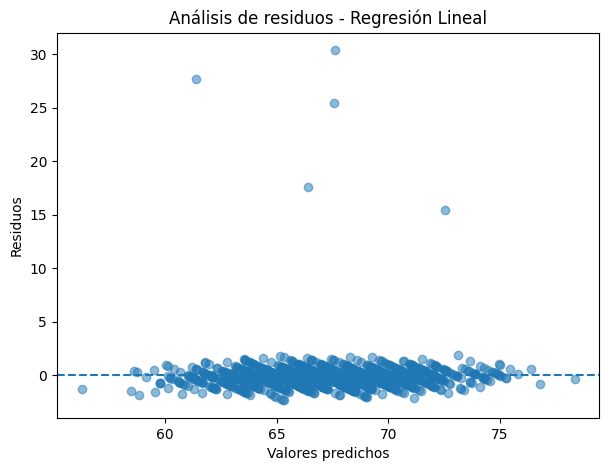

In [69]:
"Análisis de residuos"
residuos = y_test - y_pred_lineal

plt.figure(figsize=(7, 5))

plt.scatter(
    y_pred_lineal,
    residuos,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Valores predichos")
plt.ylabel("Residuos")
plt.title("Análisis de residuos - Regresión Lineal")

plt.show()

El análisis de residuos muestra que la mayoría de los errores se concentra alrededor de cero, lo que indica que el modelo realiza predicciones cercanas a los valores reales para gran parte de los estudiantes. No se observa un patrón marcado en la mayoría de los residuos. Sin embargo, existen algunos residuos positivos considerablemente altos, lo que indica que el modelo subestima ciertos puntajes de examen elevados. Estos casos extremos explican en parte que el RMSE sea mayor que el MAE y muestran una limitación del modelo para representar algunos resultados poco frecuentes.

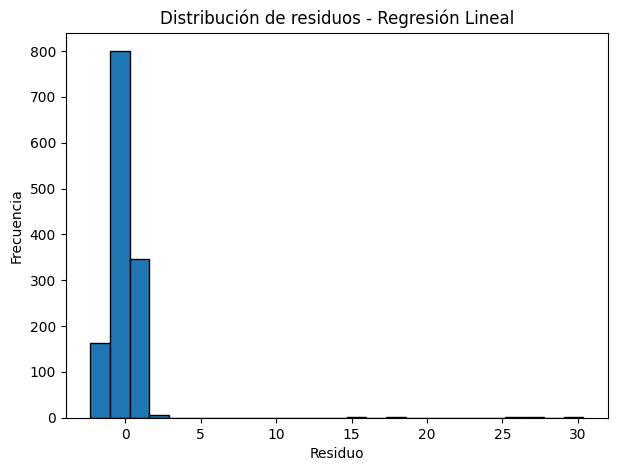

In [70]:
"Histograma"
plt.figure(figsize=(7, 5))

plt.hist(
    residuos,
    bins=25,
    edgecolor="black"
)

plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Distribución de residuos - Regresión Lineal")

plt.show()

Los residuos se concentran principalmente alrededor de cero, lo que indica que para la mayoría de las observaciones el modelo no presenta errores excesivamente grandes. Sin embargo, también se observan algunos residuos positivos de mayor magnitud. Estos corresponden principalmente a casos donde el puntaje real fue considerablemente mayor al estimado por el modelo. Por lo tanto, aunque el comportamiento general es adecuado, el modelo presenta mayores dificultades para representar algunos puntajes extremos.

In [74]:
"Encontrar los estudiantes con mayor error"
comparacion = X_test.copy()

comparacion["exam_score_real"] = y_test
comparacion["exam_score_predicho"] = y_pred_lineal

comparacion["error_absoluto"] = abs(
    comparacion["exam_score_real"]
    - comparacion["exam_score_predicho"]
)

display(comparacion.head())

,hours_studied,attendance,previous_scores,tutoring_sessions,sleep_hours,physical_activity,parental_involvement,access_to_resources,motivation_level,family_income,teacher_quality,extracurricular_activities,internet_access,school_type,learning_disabilities,exam_score_real,exam_score_predicho,error_absoluto
6415,16,82,91,0,6,3,Medium,Medium,Medium,Low,Medium,No,Yes,Public,No,66,65.731007,0.268993
6117,15,74,60,3,8,5,High,High,Low,Low,Medium,No,Yes,Public,No,66,65.653029,0.346971
239,25,87,74,0,7,4,Medium,Low,Low,Medium,High,Yes,Yes,Public,Yes,67,67.775788,0.775788
1906,11,95,81,2,6,3,Medium,Medium,High,Low,Low,No,Yes,Public,No,67,67.372239,0.372239
6097,21,93,70,0,9,1,Low,Medium,Medium,Medium,High,No,Yes,Public,No,68,68.014195,0.014195


In [83]:
"5 mejores casos"
mejores_predicciones = (
    comparacion
    .sort_values("error_absoluto")
    .head(5)
)

display(mejores_predicciones[columnas_comparacion])

,hours_studied,attendance,previous_scores,tutoring_sessions,motivation_level,parental_involvement,exam_score_real,exam_score_predicho,error_absoluto
322,15,87,80,0,High,High,67,67.000595,0.000595
4077,8,65,74,1,Medium,Medium,61,61.001574,0.001574
3397,29,83,62,4,Low,Medium,70,70.003408,0.003408
2252,11,79,71,1,Low,Medium,63,62.996326,0.003674
1913,23,100,59,2,Medium,High,72,72.004067,0.004067


In [72]:
"5 peores casos"
mayores_errores = (
    comparacion
    .sort_values(
        "error_absoluto",
        ascending=False
    )
    .head(5)
)

mayores_errores


,hours_studied,attendance,previous_scores,tutoring_sessions,sleep_hours,physical_activity,parental_involvement,access_to_resources,motivation_level,family_income,teacher_quality,extracurricular_activities,internet_access,school_type,learning_disabilities,exam_score_real,exam_score_predicho,error_absoluto
6393,16,83,92,2,8,4,Low,Medium,Low,High,High,Yes,Yes,Public,No,98,67.627661,30.372339
217,19,70,54,0,7,2,Medium,Low,High,Medium,Medium,No,Yes,Public,Yes,89,61.353832,27.646168
4583,25,73,56,2,7,4,Medium,Medium,Medium,High,Medium,Yes,Yes,Public,No,93,67.572236,25.427764
3932,25,66,55,4,7,2,High,Medium,Medium,Medium,Medium,Yes,Yes,Public,Yes,84,66.404939,17.595061
1607,30,98,93,1,9,3,Medium,Low,Medium,Low,Low,Yes,Yes,Private,No,88,72.556439,15.443561


Al comparar las observaciones con menor y mayor error absoluto, se observa que los casos mejor predichos presentan valores de Exam_Score cercanos al rango donde se concentra la mayoría de los estudiantes. En estos casos, el modelo logró diferencias prácticamente nulas entre el valor real y el predicho.

En cambio, los casos con mayor error corresponden principalmente a estudiantes con puntajes reales considerablemente altos. Por ejemplo, algunos estudiantes obtuvieron resultados cercanos a 90 o 100 puntos, mientras que el modelo estimó valores mucho menores. Aunque algunos de estos estudiantes presentan buena asistencia, puntajes anteriores altos o varias horas de estudio, sus características no parecen suficientes para explicar completamente un resultado tan elevado.

Esto sugiere que el modelo de regresión lineal representa correctamente el comportamiento general de los datos, pero tiene dificultades con observaciones poco comunes o extremas. Las diferencias podrían deberse a variables que no están incluidas en el dataset, a relaciones no lineales entre los factores o a que existen pocos ejemplos de estudiantes con puntajes extremadamente altos.

In [75]:
columnas_comparacion = [
    "hours_studied",
    "attendance",
    "previous_scores",
    "tutoring_sessions",
    "motivation_level",
    "parental_involvement",
    "exam_score_real",
    "exam_score_predicho",
    "error_absoluto"
]

display(comparacion[columnas_comparacion].head())

display(
    mayores_errores[columnas_comparacion]
)

,hours_studied,attendance,previous_scores,tutoring_sessions,motivation_level,parental_involvement,exam_score_real,exam_score_predicho,error_absoluto
6415,16,82,91,0,Medium,Medium,66,65.731007,0.268993
6117,15,74,60,3,Low,High,66,65.653029,0.346971
239,25,87,74,0,Low,Medium,67,67.775788,0.775788
1906,11,95,81,2,High,Medium,67,67.372239,0.372239
6097,21,93,70,0,Medium,Low,68,68.014195,0.014195


,hours_studied,attendance,previous_scores,tutoring_sessions,motivation_level,parental_involvement,exam_score_real,exam_score_predicho,error_absoluto
6393,16,83,92,2,Low,Low,98,67.627661,30.372339
217,19,70,54,0,High,Medium,89,61.353832,27.646168
4583,25,73,56,2,Medium,Medium,93,67.572236,25.427764
3932,25,66,55,4,Medium,High,84,66.404939,17.595061
1607,30,98,93,1,Medium,Medium,88,72.556439,15.443561


In [78]:
"Validación cruzada de 5 particiones"
from sklearn.model_selection import KFold, cross_val_score

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_mae = cross_val_score(
    modelo_lineal,
    X_train,
    y_train,
    cv=kfold,
    scoring="neg_mean_absolute_error"
)

cv_mae = -cv_mae

print("MAE por partición:")
print(cv_mae)

print("\nMAE promedio:")
print(cv_mae.mean())

print("\nDesviación estándar:")
print(cv_mae.std())

MAE por partición:
[0.75853467 0.81780434 0.88244402 0.7240222  0.75779527]

MAE promedio:
0.7881200984397261

Desviación estándar:
0.056002840624296155


En la validación cruzada de 5 particiones, el modelo obtuvo un MAE promedio de 0.7881 con una desviación estándar de 0.0560. Esto significa que, al probar el modelo con diferentes divisiones de los datos, se equivoca en promedio cerca de 0.79 puntos en Exam_Score. La desviación estándar es pequeña, por lo que los resultados entre las cinco particiones fueron bastante similares y el modelo muestra un comportamiento estable. Comparado con el MAE de 0.6615 obtenido en la división 80/20, el resultado es un poco mayor, pero sigue siendo bajo y confirma que el modelo mantiene un buen desempeño con diferentes muestras de datos.

Al revisar las observaciones con errores más altos, se observa que varios corresponden a estudiantes con puntajes reales muy elevados. Por ejemplo, un estudiante obtuvo 98 puntos, pero el modelo predijo aproximadamente 67.6, generando un error de más de 30 puntos. Esto indica que la regresión lineal funciona bien para la mayoría de los casos, pero tiene dificultades para representar algunos resultados extremos. Esto podría deberse a que existen factores que no están incluidos en el dataset o a que estos casos no siguen una relación completamente lineal.

In [79]:
"Comparar Holdout vs Cross Validation"
print("MAE Test 80/20:", mean_absolute_error(
    y_test,
    y_pred_lineal
))

print("MAE promedio CV:", cv_mae.mean())
print("Desviación estándar CV:", cv_mae.std())

MAE Test 80/20: 0.661513221783917
MAE promedio CV: 0.7881200984397261
Desviación estándar CV: 0.056002840624296155


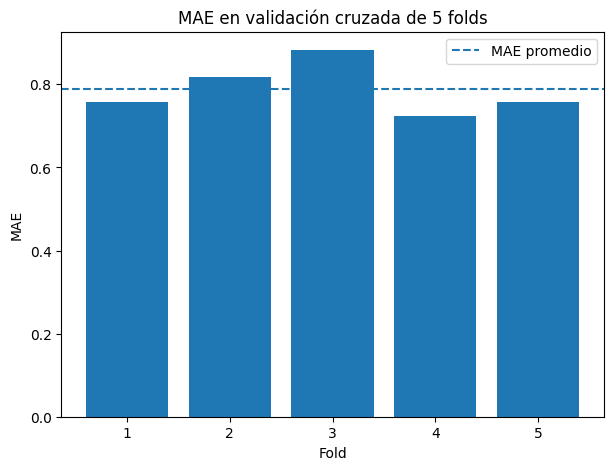

In [80]:
"visualizar los cinco resultados"
plt.figure(figsize=(7, 5))

plt.bar(
    range(1, 6),
    cv_mae
)

plt.axhline(
    cv_mae.mean(),
    linestyle="--",
    label="MAE promedio"
)

plt.xlabel("Fold")
plt.ylabel("MAE")
plt.title("MAE en validación cruzada de 5 folds")

plt.legend()
plt.show()

Los resultados de los cinco folds presentan valores de MAE similares, con un promedio de 0.7881 y una desviación estándar de 0.0560. Esto indica que el desempeño del modelo se mantiene relativamente estable al utilizar diferentes particiones de los datos. Aunque el MAE obtenido con la división 80/20 fue menor, la validación cruzada ofrece una evaluación más confiable al no depender de una sola separación del dataset.

In [81]:
"Mejora respecto de la línea base"
mae_baseline = 2.7629
mae_lineal = 0.6615

mejora_mae = (
    (mae_baseline - mae_lineal)
    / mae_baseline
) * 100

print("Reducción del MAE:", mejora_mae, "%")

Reducción del MAE: 76.05776539143653 %


En comparación con la línea base, la Regresión Lineal redujo el MAE aproximadamente un 76 %, lo que demuestra que el uso de las características de los estudiantes mejora considerablemente la estimación de Exam_Score frente a predecir únicamente un valor promedio.

Conclusión final
En esta actividad se construyeron y evaluaron modelos para estimar Exam_Score utilizando características académicas, personales y escolares de los estudiantes. La línea base obtuvo un MAE de 2.76, mientras que la Regresión Lineal redujo este valor hasta aproximadamente 0.66, lo que representa una reducción cercana al 76 % en el error absoluto promedio.

La Regresión Lineal y Ridge presentaron resultados prácticamente equivalentes, ambos con un R² cercano a 0.796. La Regresión Lineal obtuvo un MAE ligeramente menor, por lo que fue seleccionada como el mejor modelo para realizar los análisis posteriores.

Entre las variables exploradas, la asistencia y las horas de estudio mostraron algunas de las relaciones más claras con Exam_Score, mientras que otros factores como los puntajes anteriores, sesiones de tutoría, motivación y participación de los padres aportaron información adicional al modelo.

El análisis de las predicciones mostró que el modelo funciona correctamente para la mayoría de los estudiantes, aunque presenta mayores dificultades con algunos puntajes excepcionalmente altos. Esto sugiere que pueden existir factores que no están representados en las variables disponibles o relaciones que no son completamente lineales.

La validación cruzada de cinco particiones obtuvo un MAE promedio de [TU RESULTADO] con una desviación estándar de [TU RESULTADO], permitiendo comprobar si el desempeño se mantiene estable entre diferentes subconjuntos de los datos.

En conclusión, el modelo constituye una buena primera aproximación para estimar el desempeño académico, pero no debería utilizarse por sí solo para tomar decisiones académicas importantes. Como mejora futura sería conveniente probar modelos capaces de representar relaciones no lineales, ajustar hiperparámetros y validar los resultados con nuevos datos antes de utilizar el modelo en un contexto real.